# Fáza 3 - Strojové učenie: 20 bodov
Pri dátovej analýze nemusí byť naším cieľom získať len znalosti obsiahnuté v aktuálnych dátach, ale aj natrénovať model, ktorý bude schopný robiť rozumné predikcie pre nové pozorovania pomocou techniky strojového učenia. 

## 3.1 Jednoduchý klasifikátor na základe závislosti v dátach  (5b)
- (A-2b) Naimplementujte jednoduchý ID3 klasifikátor s hĺbkou min 2 (vrátane root/koreň). 
- (B-1b) Vyhodnoťte Váš ID3 klasifikátor pomocou metrík accuracy, precision a recall.
- (C-2b) Zístite či Váš ID3 klasifikátor má overfit. Ak áno, riešte aby nemal overfitting.

## 3.2 Trénovanie a vyhodnotenie klasifikátorov strojového učenia (5b)
- (A-1b) Na trénovanie využite jeden stromový algoritmus v scikit-learn.
- (B-1b) Porovnajte s jedným iným nestromovým algoritmom v scikit-learn.
- (C-1b) Porovnajte výsledky s ID3 z prvého kroku.
- (D-1b) Vizualizujte natrénované pravidlá minimálne pre jeden Vami vybraný algoritmus
- (E-1b) Vyhodnoťte natrénované modely pomocou metrík accuracy, precision a recall

## 3.3 Optimalizácia alias hyperparameter tuning (5b)
- (A-1b) Vyskúšajte rôzne nastavenie hyperparametrov (tuning) pre zvolený algoritmus tak, aby ste optimalizovali výkonnosť (bez underfitingu).
- (B-1b) Vyskúšajte kombinácie modelov (ensemble) pre zvolený algoritmus tak, aby ste optimalizovali výkonnosť (bez underfitingu). 
- (C-1b) Využite krížovú validáciu (cross validation) na trénovacej množine.
- (D-2b) Dokážte že Váš nastavený najlepší model je bez overfitingu.

## 3.4 Vyhodnotenie vplyvu zvolenej stratégie riešenia na klasifikáciu (5b) 
Vyhodnoťte Vami zvolené stratégie riešenia projektu z hľadiska classification accuracy, či sú učinné pre Váš dataset: 
- (A-1b) Stratégie riešenia v data preprocessingu s daným datasetom.
- (B-1b) Dátová transformácia (scaling, transformer, …)
- (C-1b) Výber atribútov, výber algoritmov, hyperparameter tuning, ensemble learning
- (D-1b) Ktorý model je Váš najlepší model pre nasadenie (deployment)? 
- (E-1b) Aký je data pipeline pre jeho vybudovanie na základe Vášho datasetu v produkcii?

Všetky hodnotenia podložte dôkazmi. Najlepší model má byť stabilný, bez overfitu a bez underfitu. Jeho data pipeline má byť dodaný s metadátami, ak tie metadáta sú potrebné a vyrobené v developmente.

In [17]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer, RobustScaler
from sklearn.pipeline import Pipeline
from collections import Counter
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score

In [18]:
mpl.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.family"] = "DejaVu Sans"
sns.set_theme(palette="vanimo")

In [19]:
os.makedirs("pickles_ph3", exist_ok=True)

In [20]:
def histogramiada(df, bins=30):
    numeric_cols = df.select_dtypes(include=np.number).columns
    n_cols = len(numeric_cols)

    if n_cols == 0:
        print("[!] No numeric columns to plot.")
        return

    per_page = 9
    n_pages = int(np.ceil(n_cols / per_page))

    for page in range(n_pages):
        start = page * per_page
        end = start + per_page
        cols_subset = numeric_cols[start:end]

        fig, axes = plt.subplots(3, 3, figsize=(12, 10))
        axes = axes.flatten()

        for i, col in enumerate(cols_subset):
            sns.histplot(df[col], bins=bins, kde=True, ax=axes[i],
                         color=sns.color_palette("tab10")[i % 10])
            axes[i].set_title(col, fontsize=11)
            axes[i].set_xlabel("")
            axes[i].set_ylabel("")

        # hide unused subplots if fewer than 9
        for j in range(len(cols_subset), len(axes)):
            axes[j].set_visible(False)

        plt.suptitle(f"Top features {start + 1}–{min(end, n_cols)}", fontsize=13)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

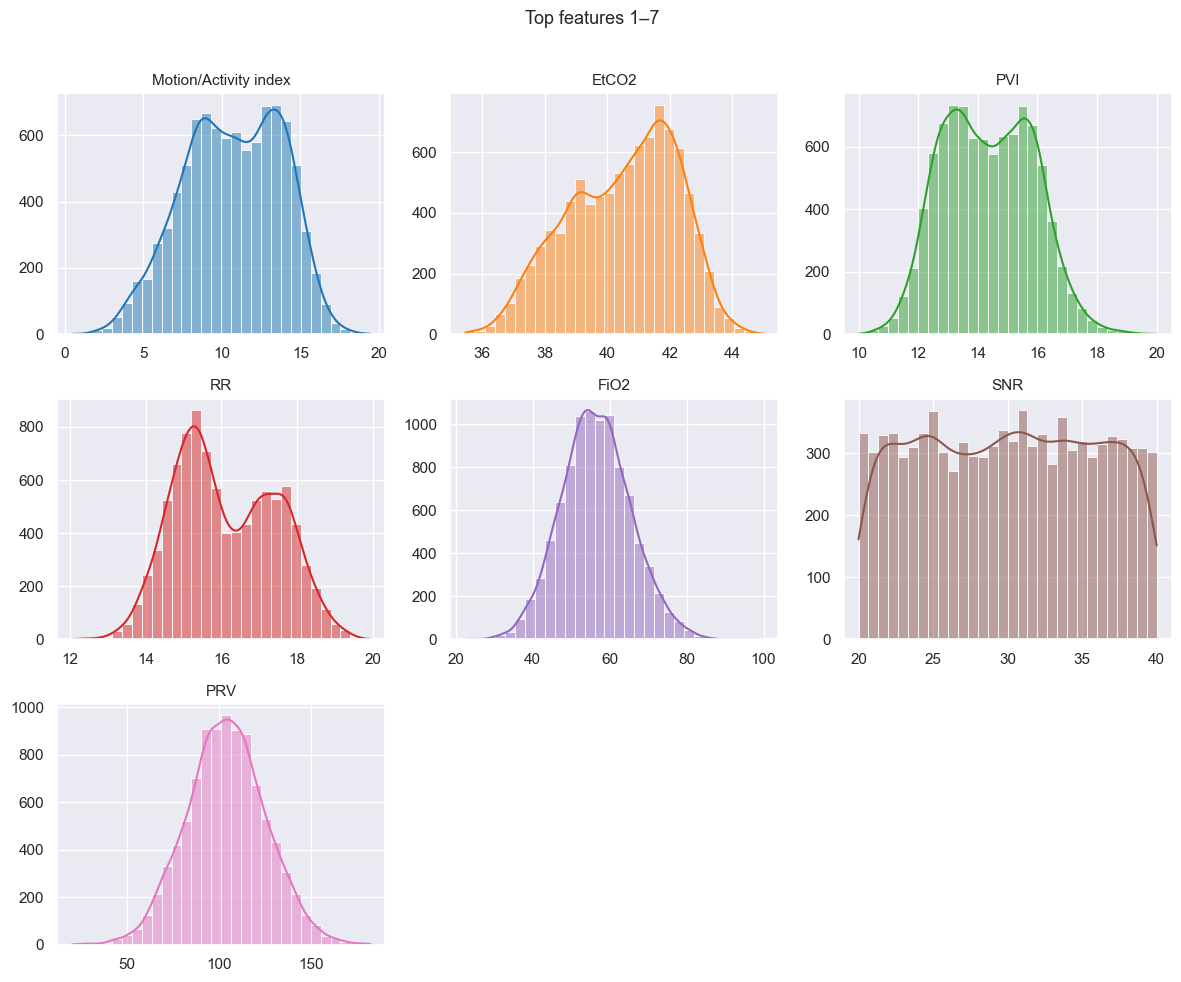

(9495, 7)
(9495,)


['pickles_ph3/preprocessing_pipeline.pkl']

In [21]:
df_observation = pd.read_csv('datasets/observation.csv',sep='\t')

df_observation.rename(
    columns={
        "SpO₂": "SpO2",
        "EtCO₂": "EtCO2",
        "FiO₂": "FiO2",
        "O₂ extraction ratio": "O2 extraction ratio"
    },
    inplace=True
)

# vieme z fazy 2
selected_features = ["Motion/Activity index", "EtCO2", "PVI", "RR", "FiO2", "SNR", "PRV", "oximetry"]

df = df_observation[selected_features]

df = df.drop_duplicates().reset_index(drop=True)

X = df.drop(columns=['oximetry'])
y = df['oximetry']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

histogramiada(X_train)

pipeline = Pipeline(
    steps=[
        ('quantile_transformer', QuantileTransformer(output_distribution='normal', random_state=42)),
        ('robust_scaler', RobustScaler())
    ]
)

pipeline.fit(X_train)

X_train_processed = pipeline.transform(X_train)
X_test_processed  = pipeline.transform(X_test)

X_train_df = pd.DataFrame(X_train_processed, columns=X_train.columns, index=X_train.index)
X_test_df  = pd.DataFrame(X_test_processed,  columns=X_test.columns,  index=X_test.index)

train_final = pd.concat([X_train_df, y_train], axis=1)
test_final  = pd.concat([X_test_df,  y_test],  axis=1)

train_final.to_csv("processed_train.csv", index=False)
test_final.to_csv("processed_test.csv", index=False)

joblib.dump(pipeline, "pickles_ph3/preprocessing_pipeline.pkl")

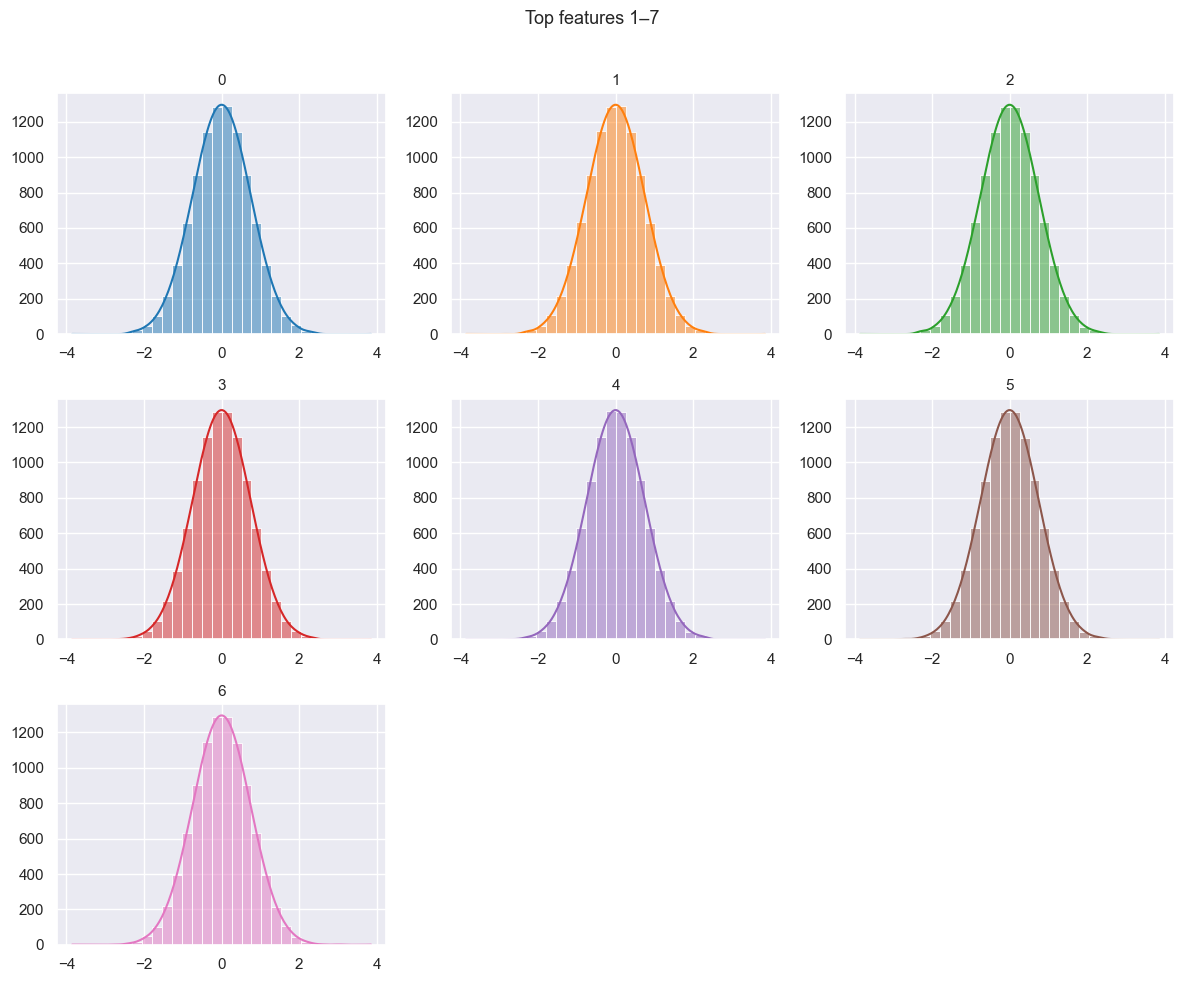

In [22]:
histogramiada(pd.DataFrame(X_train_processed))

# 3.1 Jednoduchý klasifikátor na základe závislosti v dátach

#### 3.1A Naimplementujte jednoduchý ID3 klasifikátor s hĺbkou min 2 (vrátane root/koreň).

In [23]:
class ID3Classifier:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def entropy(self, y):
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return -np.sum(probabilities * np.log2(probabilities))

    def information_gain(self, X_column, y, threshold):
        parent_entropy = self.entropy(y)

        left_mask = X_column <= threshold
        right_mask = ~left_mask

        if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
            return 0

        n = len(y)
        n_left, n_right = np.sum(left_mask), np.sum(right_mask)
        e_left = self.entropy(y[left_mask])
        e_right = self.entropy(y[right_mask])
        child_entropy = (n_left / n) * e_left + (n_right / n) * e_right

        return parent_entropy - child_entropy

    def find_best_split(self, X, y):
        best_gain = -1
        best_feature = None
        best_threshold = None

        n_features = X.shape[1]

        for feature_idx in range(n_features):
            X_column = X[:, feature_idx]
            thresholds = np.unique(X_column)

            for threshold in thresholds:
                gain = self.information_gain(X_column, y, threshold)

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = threshold

        return best_feature, best_threshold, best_gain

    def build_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        if (self.max_depth is not None and depth >= self.max_depth) or \
           n_labels == 1 or \
           n_samples < self.min_samples_split:
            leaf_value = Counter(y).most_common(1)[0][0]
            return {'leaf': True, 'value': leaf_value}

        best_feature, best_threshold, best_gain = self.find_best_split(X, y)

        if best_gain == 0:
            leaf_value = Counter(y).most_common(1)[0][0]
            return {'leaf': True, 'value': leaf_value}

        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask

        left_subtree = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self.build_tree(X[right_mask], y[right_mask], depth + 1)

        return {
            'leaf': False,
            'feature': best_feature,
            'threshold': best_threshold,
            'left': left_subtree,
            'right': right_subtree
        }

    def fit(self, X, y):
        self.tree = self.build_tree(X, y)
        return self

    def predict_sample(self, x, tree):
        if tree['leaf']:
            return tree['value']

        if x[tree['feature']] <= tree['threshold']:
            return self.predict_sample(x, tree['left'])
        else:
            return self.predict_sample(x, tree['right'])

    def predict(self, X):
        return np.array([self.predict_sample(x, self.tree) for x in X])

    def score(self, X, y):
        predictions = self.predict(X)
        return np.mean(predictions == y)


In [24]:
X_train_np = np.array(X_train)
X_test_np = np.array(X_test)
y_train_np = np.array(y_train)
y_test_np = np.array(y_test)

clf = ID3Classifier(max_depth=2)
clf.fit(X_train_np, y_train_np)

y_pred_train = clf.predict(X_train_np)
y_pred_test = clf.predict(X_test_np)

train_accuracy = accuracy_score(y_train_np, y_pred_train)
test_accuracy = accuracy_score(y_test_np, y_pred_test)

accuracy_diff = abs(test_accuracy - train_accuracy)
is_overfitting = accuracy_diff >= 0.1

id3_results = {
    "Accuracy": accuracy_score(y_test_np, y_pred_test),
    "Precision": precision_score(y_test_np, y_pred_test, average="weighted", zero_division=0),
    "Recall": recall_score(y_test_np, y_pred_test, average="weighted", zero_division=0)
}

print("=" * 60)
print("TRAINING SET RESULTS")
print("=" * 60)
print(f"Accuracy: {train_accuracy:.4f}\n")
print(classification_report(y_train_np, y_pred_train))

print("=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
print(f"Accuracy: {test_accuracy:.4f}\n")
print(classification_report(y_test_np, y_pred_test))

print("=" * 60)
print("OVERFITTING EVALUATION")
print("=" * 60)
print(f"Accuracy Difference: {accuracy_diff:.4f}")
print(f"Overfitting Threshold: 0.1000")

if is_overfitting:
    print("[!] Model is OVERFITTING!")
else:
    print("[+] Model is NOT overfitting")

TRAINING SET RESULTS
Accuracy: 0.8074

              precision    recall  f1-score   support

         0.0       0.70      0.93      0.80      3851
         1.0       0.94      0.73      0.82      5644

    accuracy                           0.81      9495
   macro avg       0.82      0.83      0.81      9495
weighted avg       0.84      0.81      0.81      9495

TEST SET RESULTS
Accuracy: 0.8184

              precision    recall  f1-score   support

         0.0       0.71      0.92      0.80       952
         1.0       0.94      0.75      0.83      1422

    accuracy                           0.82      2374
   macro avg       0.82      0.84      0.82      2374
weighted avg       0.85      0.82      0.82      2374

OVERFITTING EVALUATION
Accuracy Difference: 0.0111
Overfitting Threshold: 0.1000
[+] Model is NOT overfitting


# Nacítanie dát z fázy 2

In [41]:
# Načítame CSV súbory, ktoré ste vytvorili vo fáze 2
df_train = pd.read_csv('processed_train.csv')
df_test = pd.read_csv('processed_test.csv')

print(f"Train set: {df_train.shape}")
print(f"Test set: {df_test.shape}")

print(f"\nNázvy stĺpcov v train:")
print(df_train.columns.tolist())

print(f"\nPrvých 5 riadkov train:")
print(df_train.head())

Train set: (9495, 8)
Test set: (2374, 8)

Názvy stĺpcov v train:
['Motion/Activity index', 'EtCO2', 'PVI', 'RR', 'FiO2', 'SNR', 'PRV', 'oximetry']

Prvých 5 riadkov train:
   Motion/Activity index     EtCO2       PVI        RR      FiO2       SNR  \
0              -0.595359 -0.491404 -0.949250 -0.002626 -1.006420  0.502873   
1               0.463407  0.539680 -1.652334 -0.763705  0.011296  0.643252   
2              -0.619198 -0.132181 -0.398580 -0.197671 -0.481101 -0.213602   
3              -0.276938  0.811081 -0.276738 -1.816232 -0.328481 -0.282561   
4              -0.802986 -0.279852  0.129983 -0.340129  0.745828 -1.114274   

        PRV  oximetry  
0 -0.962983       0.0  
1  0.672515       1.0  
2  0.268814       1.0  
3  0.280815       0.0  
4 -0.360338       0.0  


In [56]:
# Kontrola NaN hodnôt
print(f"\nNaN hodnoty v train:")
print(df_train.isnull().sum())

print(f"\nNaN hodnoty v test:")
print(df_test.isnull().sum())


NaN hodnoty v train:
Motion/Activity index    0
EtCO2                    0
PVI                      0
RR                       0
FiO2                     0
SNR                      0
PRV                      0
oximetry                 0
dtype: int64

NaN hodnoty v test:
Motion/Activity index    0
EtCO2                    0
PVI                      0
RR                       0
FiO2                     0
SNR                      0
PRV                      0
oximetry                 0
dtype: int64


In [102]:
target_col = 'oximetry' if 'oximetry' in df_train.columns else None
print(f"\nTarget premenná: {target_col}")


Target premenná: oximetry


In [44]:
# Rozdelenie na features a target
feature_cols = [col for col in df_train.columns if col != target_col]

X_train = df_train[feature_cols]
y_train = df_train[target_col]

X_test = df_test[feature_cols]
y_test = df_test[target_col]

print(f"\nX_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")


X_train: (9495, 7)
y_train: (9495,)
X_test: (2374, 7)
y_test: (2374,)


In [103]:
print(f"\nFeatures ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

print(f"\nTarget distribution (train):")
print(y_train.value_counts())

print(f"\nTarget distribution (test):")
print(y_test.value_counts())


Features (7):
  1. Motion/Activity index
  2. EtCO2
  3. PVI
  4. RR
  5. FiO2
  6. SNR
  7. PRV

Target distribution (train):
oximetry
1.0    5644
0.0    3851
Name: count, dtype: int64

Target distribution (test):
oximetry
1.0    1422
0.0     952
Name: count, dtype: int64


Konverzia na numpy arrays pre sklearn

In [47]:
X_train_scaled = X_train.values
X_test_scaled = X_test.values
y_train_np = y_train.values
y_test_np = y_test.values

# 3.2 Trénovanie a vyhodnotenie klasifikátorov strojového učenia

## A) Stromový algoritmus

In [51]:
# Sklearn - modely
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Sklearn - metriky a vizualizácia
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.tree import plot_tree

# Nastavenie vizualizácie
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

RANDOM_STATE = 42

#### DecisionTreeClassifier

In [96]:
dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=RANDOM_STATE
)
dt_model.fit(X_train_scaled, y_train_np)
y_pred_dt = dt_model.predict(X_test_scaled)

In [117]:
print("\nDECISION TREE – CLASSIFICATION REPORT")
print(classification_report(y_test_np, y_pred_dt, zero_division=0))


DECISION TREE – CLASSIFICATION REPORT
              precision    recall  f1-score   support

         0.0       0.89      0.90      0.90       952
         1.0       0.93      0.93      0.93      1422

    accuracy                           0.92      2374
   macro avg       0.91      0.91      0.91      2374
weighted avg       0.92      0.92      0.92      2374



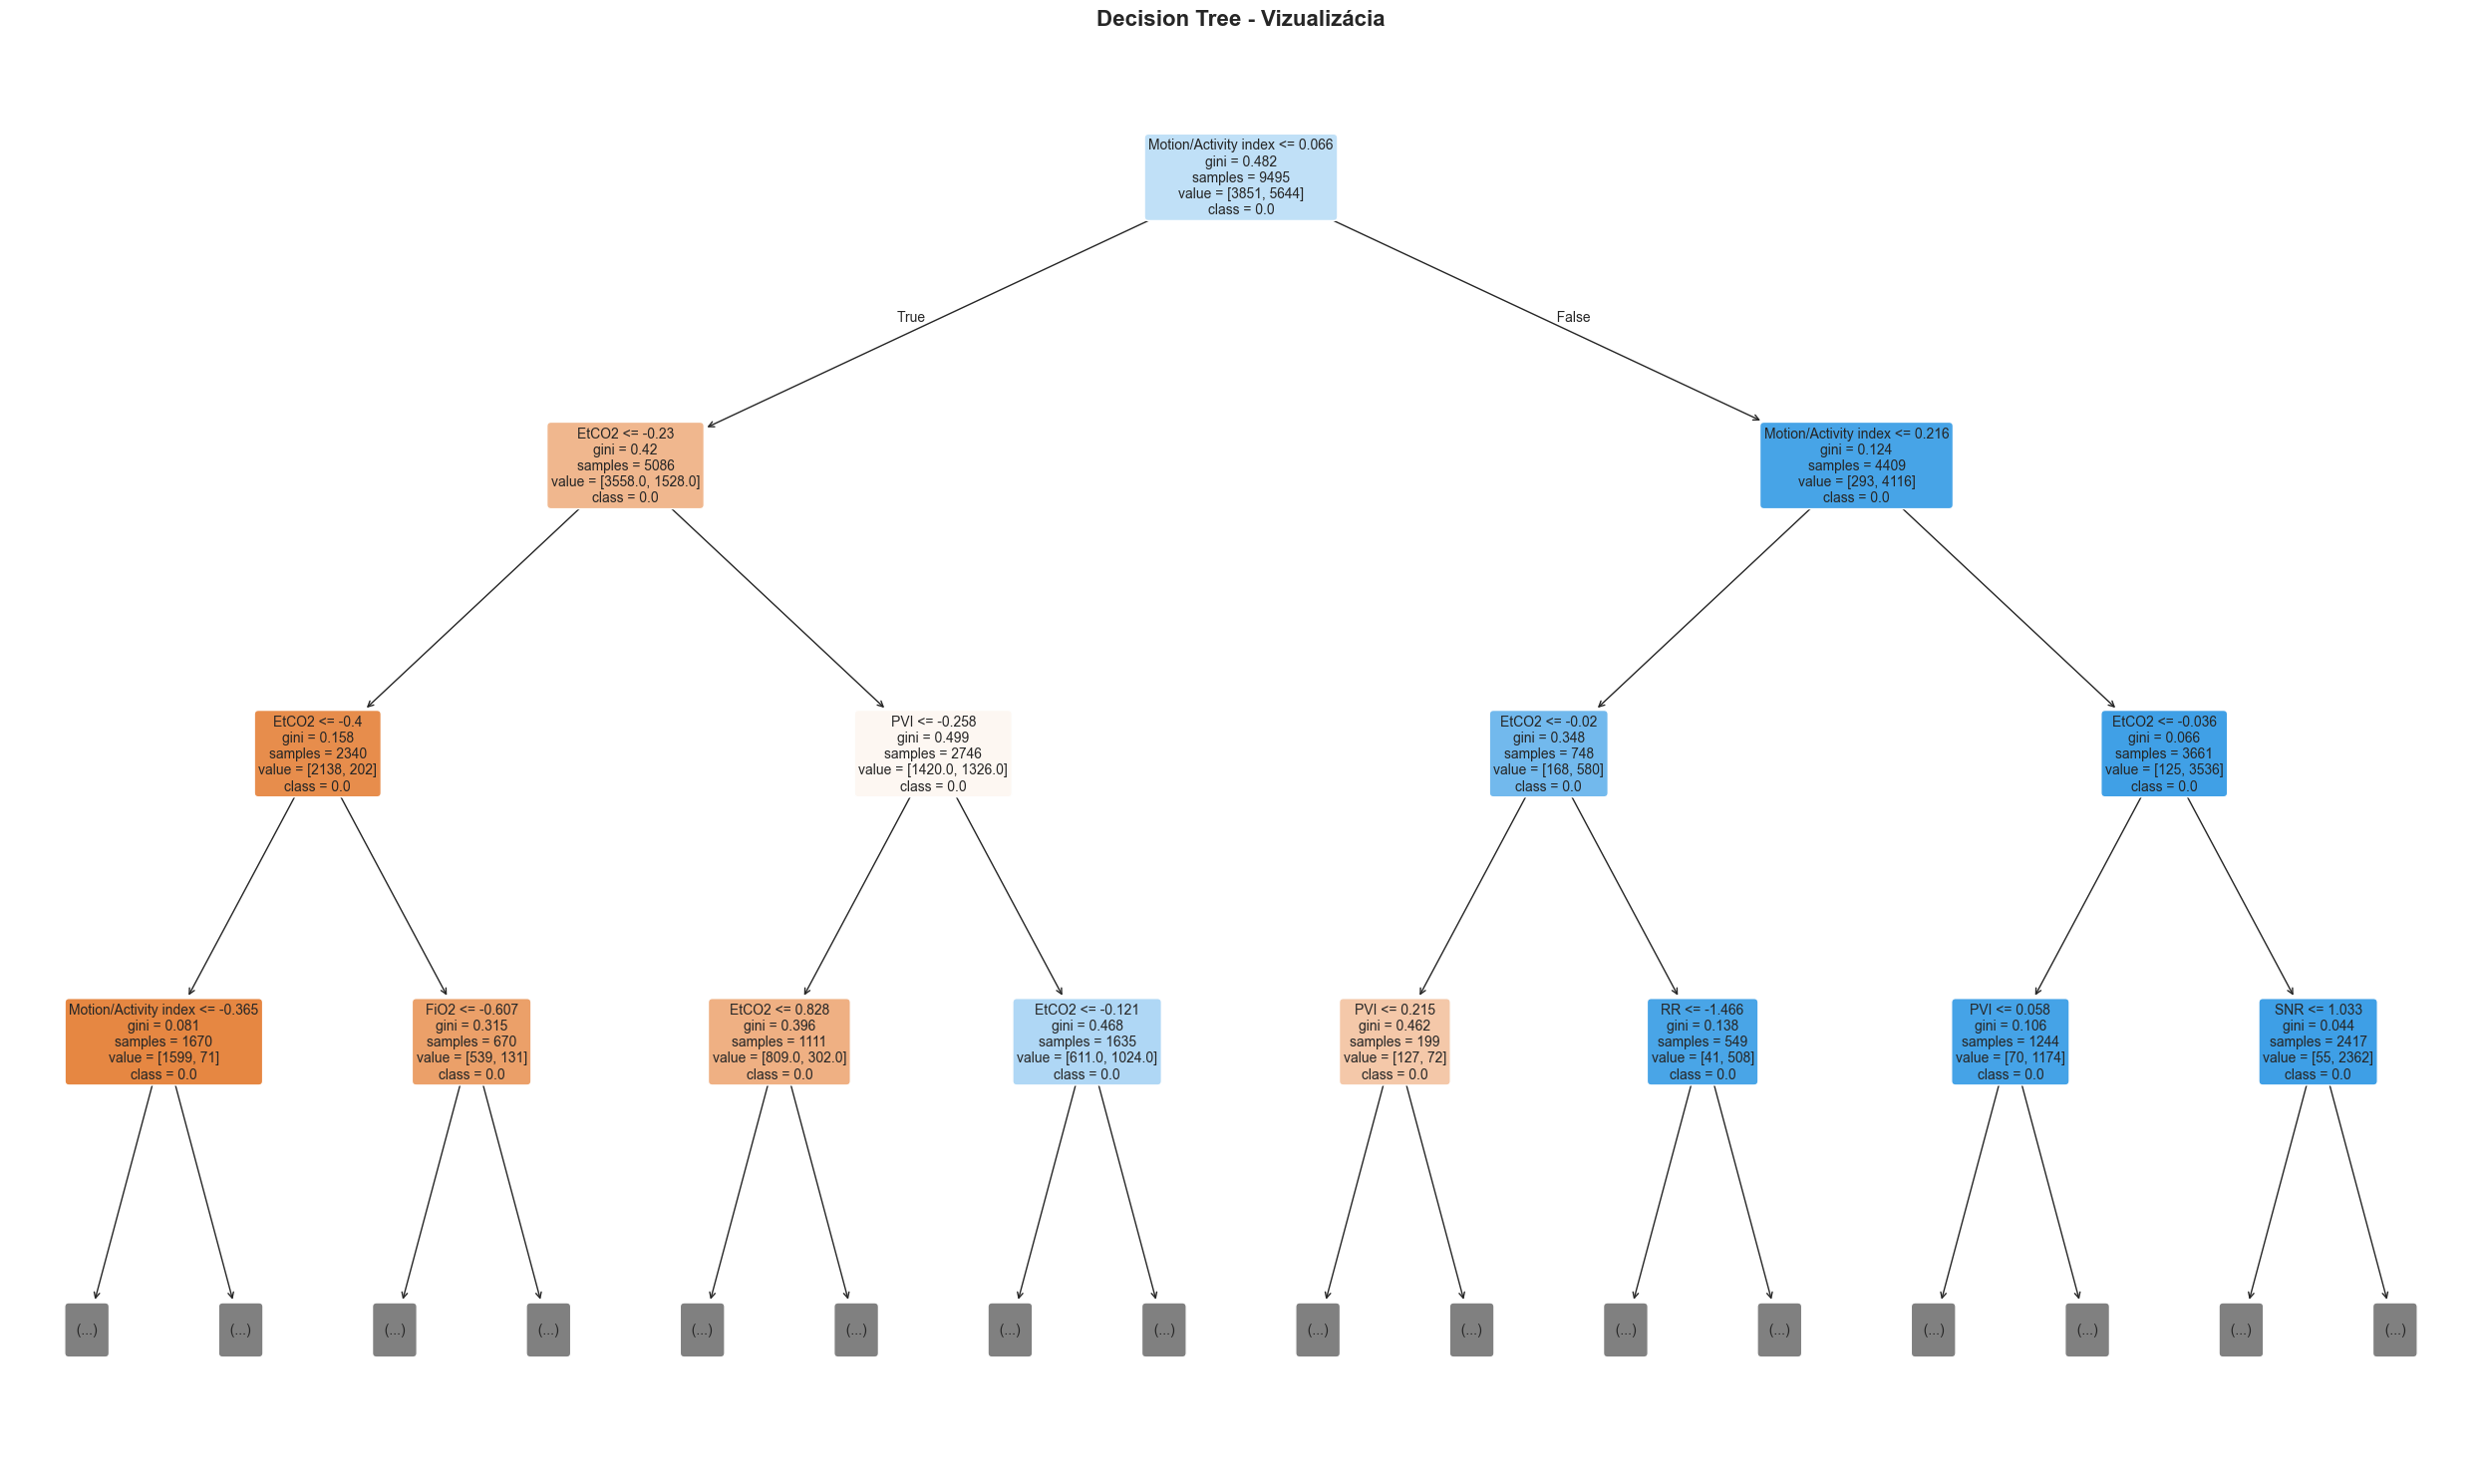

In [135]:
plt.figure(figsize=(25, 15))
plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=[str(c) for c in sorted(y_train_np)],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)

plt.title('Decision Tree - Vizualizácia', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### RandomForestClassifier

In [97]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train_np)
y_pred_rf = rf_model.predict(X_test_scaled)

In [118]:
print("\nRANDOM FOREST – CLASSIFICATION REPORT")
print(classification_report(y_test_np, y_pred_rf, zero_division=0))


RANDOM FOREST – CLASSIFICATION REPORT
              precision    recall  f1-score   support

         0.0       0.93      0.92      0.93       952
         1.0       0.95      0.95      0.95      1422

    accuracy                           0.94      2374
   macro avg       0.94      0.94      0.94      2374
weighted avg       0.94      0.94      0.94      2374



## B) Nestromové algoritmy

#### LogisticRegression

In [52]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    multi_class='multinomial',
    solver='lbfgs'
)
lr_model.fit(X_train_scaled, y_train_np)
y_pred_lr = lr_model.predict(X_test_scaled)

In [119]:
print("\nRANDOM FOREST – CLASSIFICATION REPORT")
print(classification_report(y_test_np, y_pred_lr, zero_division=0))


RANDOM FOREST – CLASSIFICATION REPORT
              precision    recall  f1-score   support

         0.0       0.84      0.81      0.82       952
         1.0       0.87      0.90      0.89      1422

    accuracy                           0.86      2374
   macro avg       0.86      0.85      0.86      2374
weighted avg       0.86      0.86      0.86      2374



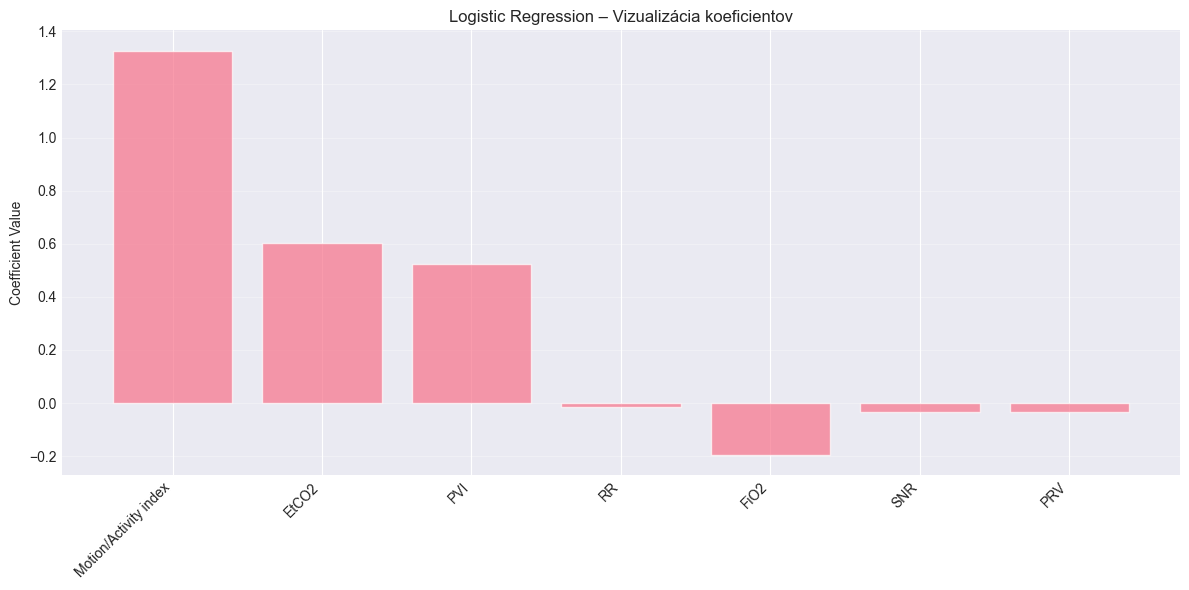

In [126]:
import matplotlib.pyplot as plt
import numpy as np

coef = lr_model.coef_[0]  # iba jedna sada váh

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(np.arange(len(coef)), coef, alpha=0.7)

ax.set_xticks(np.arange(len(X_train.columns)))
ax.set_xticklabels(X_train.columns, rotation=45, ha="right")
ax.set_ylabel("Coefficient Value")
ax.set_title("Logistic Regression")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#### SVC

In [53]:
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=RANDOM_STATE
)

svm_model.fit(X_train_scaled, y_train_np)
y_pred_svm = svm_model.predict(X_test_scaled)

In [120]:
print("\nRANDOM FOREST – CLASSIFICATION REPORT")
print(classification_report(y_test_np, y_pred_svm, zero_division=0))


RANDOM FOREST – CLASSIFICATION REPORT
              precision    recall  f1-score   support

         0.0       0.90      0.90      0.90       952
         1.0       0.93      0.93      0.93      1422

    accuracy                           0.92      2374
   macro avg       0.91      0.91      0.91      2374
weighted avg       0.92      0.92      0.92      2374



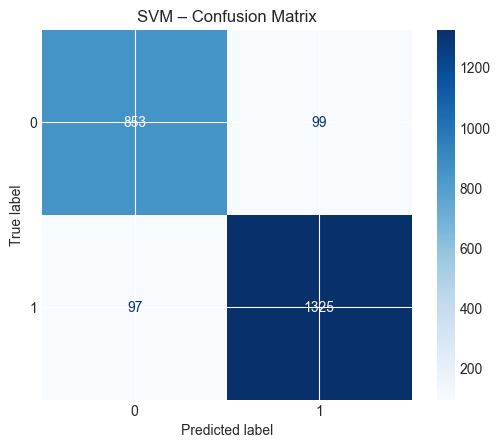

In [137]:
cm = confusion_matrix(y_test_np, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("SVM – Confusion Matrix")
plt.show()

#### KNN

In [54]:
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance'
)
knn_model.fit(X_train_scaled, y_train_np)
y_pred_knn = knn_model.predict(X_test_scaled)

In [121]:
print("\nRANDOM FOREST – CLASSIFICATION REPORT")
print(classification_report(y_test_np, y_pred_knn, zero_division=0))


RANDOM FOREST – CLASSIFICATION REPORT
              precision    recall  f1-score   support

         0.0       0.93      0.89      0.91       952
         1.0       0.93      0.95      0.94      1422

    accuracy                           0.93      2374
   macro avg       0.93      0.92      0.92      2374
weighted avg       0.93      0.93      0.93      2374



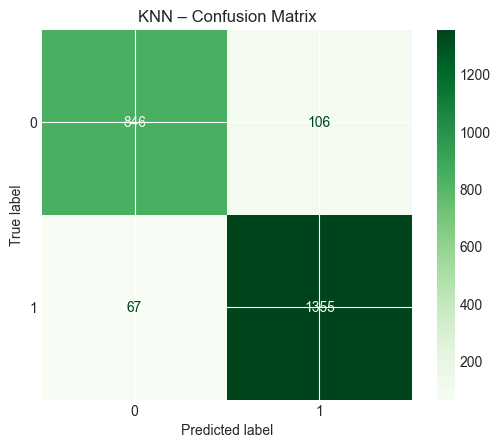

In [130]:
cm = confusion_matrix(y_test_np, y_pred_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Greens", values_format="d")
plt.title("KNN – Confusion Matrix")
plt.show()

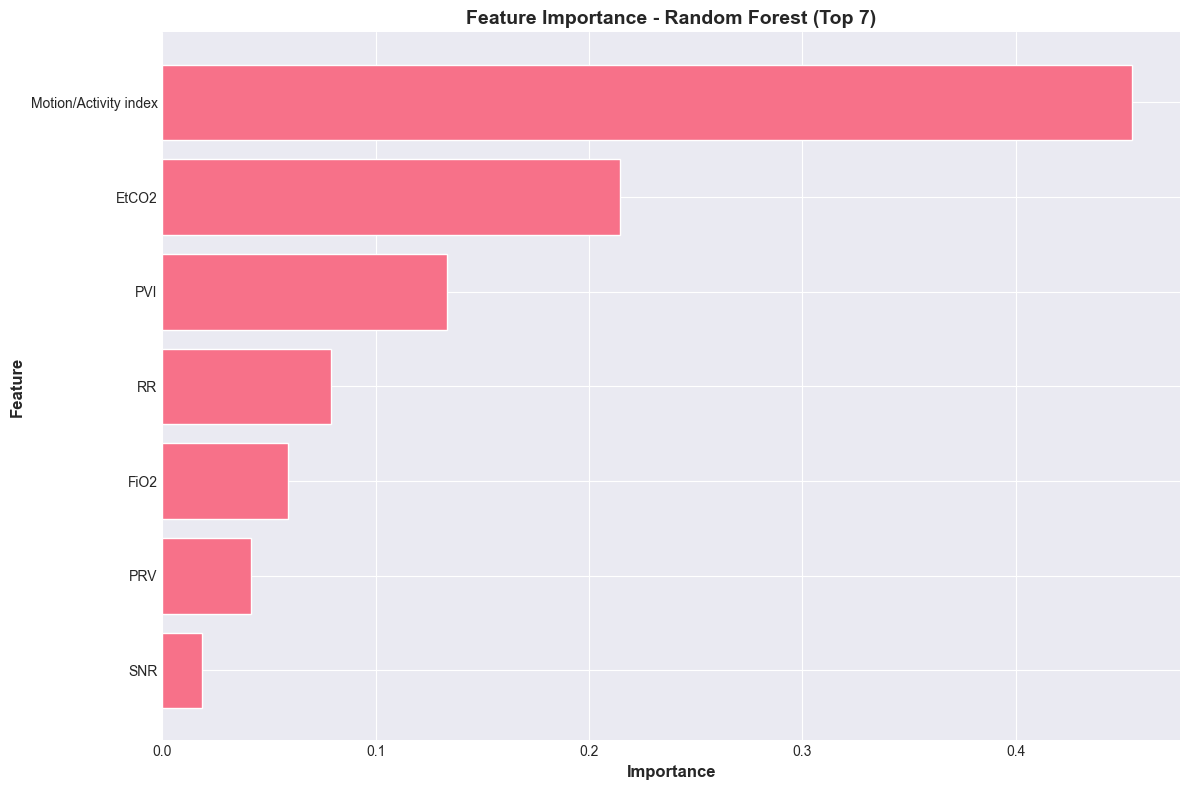

In [138]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title(f'Feature Importance - Random Forest (Top {len(feature_importance)})', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Porovnanie všetkých modelov

In [104]:
def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall
    }

results = []
results.append(evaluate_model(y_test_np, y_pred_dt, 'Decision Tree'))
results.append(evaluate_model(y_test_np, y_pred_rf, 'Random Forest'))
results.append(evaluate_model(y_test_np, y_pred_lr, 'Logistic Regression'))
results.append(evaluate_model(y_test_np, y_pred_svm, 'SVM'))
results.append(evaluate_model(y_test_np, y_pred_knn, 'KNN'))

df_results = pd.DataFrame(results)
df_results = df_results.sort_values('Accuracy', ascending=False)

print("\nPOROVNANIE VŠETKÝCH MODELOV")
print("*"*60)
print(df_results.to_string(index=False))


POROVNANIE VŠETKÝCH MODELOV
************************************************************
              Model  Accuracy  Precision   Recall
      Random Forest  0.942291   0.942237 0.942291
                KNN  0.927127   0.927114 0.927127
                SVM  0.917439   0.917411 0.917439
      Decision Tree  0.915333   0.915531 0.915333
Logistic Regression  0.862258   0.861724 0.862258


### C) Porovnajte výsledky s ID3 z prvého kroku.

In [109]:
print("\nID3 Classifier Results:")
print("*"*50)
print(f"Test Accuracy:  {id3_results['Accuracy']:.4f}")
print(f"Precision:      {id3_results['Precision']:.4f}")
print(f"Recall:         {id3_results['Recall']:.4f}")


ID3 Classifier Results:
**************************************************
Test Accuracy:  0.8184
Precision:      0.8500
Recall:         0.8200


In [113]:
df_comparison = pd.concat([
    df_results,
    pd.DataFrame([id3_results])
], ignore_index=True)

df_comparison = df_comparison.drop(columns=["F1-Score"])
df_comparison = df_comparison.sort_values('Accuracy', ascending=False)

print("POROVNANIE VŠETKÝCH MODELOV VRÁTANE ID3")
print("*"*80)
print(df_comparison.to_string(index=False))

POROVNANIE VŠETKÝCH MODELOV VRÁTANE ID3
********************************************************************************
                Model  Accuracy  Precision   Recall
        Random Forest  0.942291   0.942237 0.942291
                  KNN  0.927127   0.927114 0.927127
                  SVM  0.917439   0.917411 0.917439
        Decision Tree  0.915333   0.915531 0.915333
  Logistic Regression  0.862258   0.861724 0.862258
ID3 (custom, depth=2)  0.818400   0.850000 0.820000


In [85]:
best_sklearn_model = df_results.iloc[0]
id3_model = df_comparison[df_comparison['Model'].str.contains('ID3')].iloc[0]

print(f"\nNajlepší sklearn: {best_sklearn_model['Model']}")
print(f"  Accuracy:  {best_sklearn_model['Accuracy']:.4f}")
print(f"  Precision: {best_sklearn_model['Precision']:.4f}")
print(f"  Recall:    {best_sklearn_model['Recall']:.4f}")

print(f"\nID3: {id3_model['Model']}")
print(f"  Accuracy:  {id3_model['Accuracy']:.4f}")
print(f"  Precision: {id3_model['Precision']:.4f}")
print(f"  Recall:    {id3_model['Recall']:.4f}")

print(f"\n{id3_model['Model']} vs {best_sklearn_model['Model']}")
print(f"  Accuracy:  {best_sklearn_model['Accuracy'] - id3_model['Accuracy']:+.4f}")
print(f"  Precision: {best_sklearn_model['Precision'] - id3_model['Precision']:+.4f}")
print(f"  Recall:    {best_sklearn_model['Recall'] - id3_model['Recall']:+.4f}")

acc_improvement = ((best_sklearn_model['Accuracy'] - id3_model['Accuracy']) / id3_model['Accuracy']) * 100
print(f"\nPercentuálne zlepšenie: {acc_improvement:+.2f}%")


Najlepší sklearn: Random Forest
  Accuracy:  0.9423
  Precision: 0.9422
  Recall:    0.9423
  F1-Score:  0.9423

ID3: ID3 (custom, depth=2)
  Accuracy:  0.8184
  Precision: 0.8500
  Recall:    0.8200
  F1-Score:  0.8200

ID3 (custom, depth=2) vs Random Forest
  Accuracy:  +0.1239
  Precision: +0.0922
  Recall:    +0.1223
  F1-Score:  +0.1223

Percentuálne zlepšenie: +15.14%


### D) Vizualizujte natrénované pravidlá minimálne pre jeden Vami vybraný algoritmus

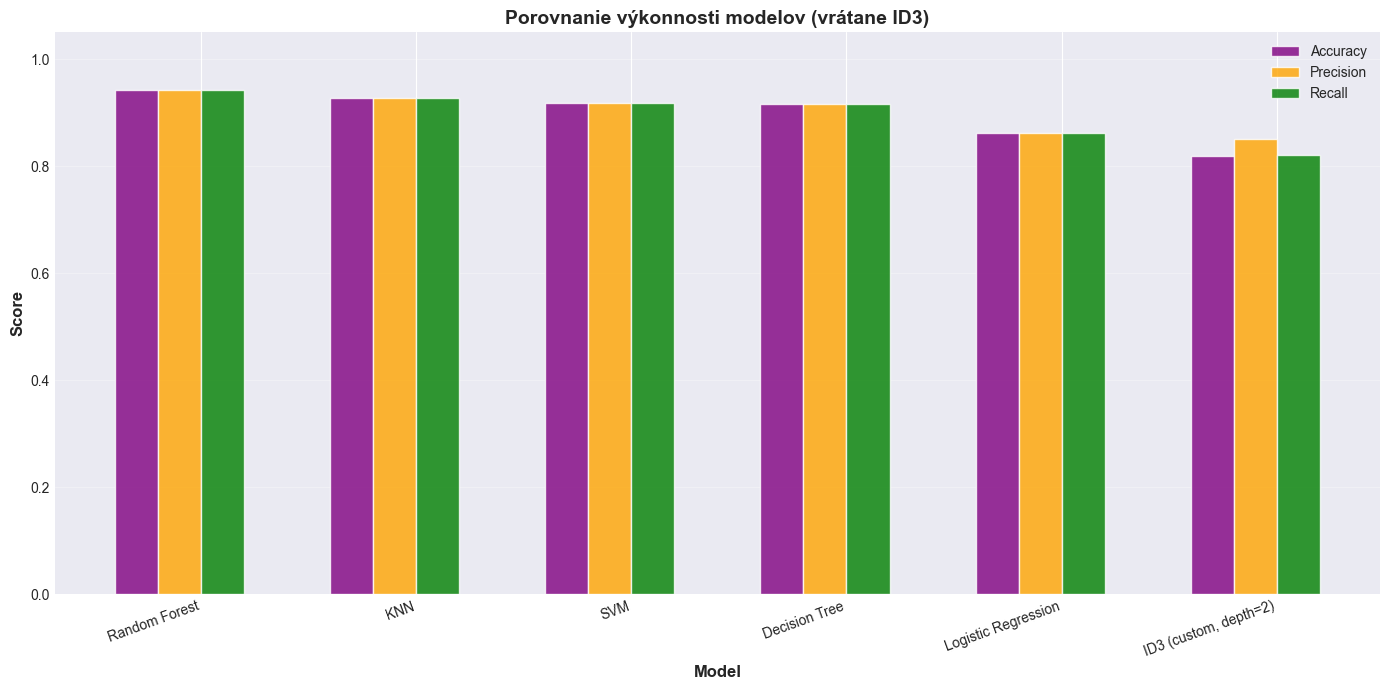

In [140]:
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(df_comparison))
width = 0.2

ax.bar(x - 1.5*width, df_comparison['Accuracy'], width, 
       label='Accuracy', alpha=0.8, color='purple')

ax.bar(x - 0.5*width, df_comparison['Precision'], width, 
       label='Precision', alpha=0.8, color='orange')

ax.bar(x + 0.5*width, df_comparison['Recall'], width, 
       label='Recall', alpha=0.8, color='green')

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Porovnanie výkonnosti modelov (vrátane ID3)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_comparison['Model'], rotation=20, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

### E) Vyhodnoťte natrénované modely pomocou metrík accuracy, precision a recall

In [142]:
df_comparison = pd.concat([
    df_results,
    pd.DataFrame([id3_results])
], ignore_index=True)

df_comparison = df_comparison.drop(columns=["F1-Score"])
df_comparison = df_comparison.sort_values('Accuracy', ascending=False)

print("\nPOROVNANIE VŠETKÝCH MODELOV VRÁTANE ID3")
print("*"*80)
print(df_comparison.to_string(index=False))


POROVNANIE VŠETKÝCH MODELOV VRÁTANE ID3
********************************************************************************
                Model  Accuracy  Precision   Recall
        Random Forest  0.942291   0.942237 0.942291
                  KNN  0.927127   0.927114 0.927127
                  SVM  0.917439   0.917411 0.917439
        Decision Tree  0.915333   0.915531 0.915333
  Logistic Regression  0.862258   0.861724 0.862258
ID3 (custom, depth=2)  0.818400   0.850000 0.820000


## Vyhodnotenie vplyvu zvolenej stratégie riešenia na klasifikáciu

In [155]:
# Najlepší model
best_model = df_comparison.iloc[0]
print(f"\nNAJLEPŠÍ MODEL: {best_model['Model']}")
print(f"   {'='*60}")
print(f"   Accuracy:  {best_model['Accuracy']:.4f} ({best_model['Accuracy']*100:.2f}%)")
print(f"   Precision: {best_model['Precision']:.4f} ({best_model['Precision']*100:.2f}%)")
print(f"   Recall:    {best_model['Recall']:.4f} ({best_model['Recall']*100:.2f}%)")


NAJLEPŠÍ MODEL: Random Forest
   Accuracy:  0.9423 (94.23%)
   Precision: 0.9422 (94.22%)
   Recall:    0.9423 (94.23%)


- Accuracy 94.2% znamená, že model správne klasifikuje 94.2% všetkých vzoriek.
- Precision 94.2% znamená, že z predikovaných pozitívnych prípadov je 94.2% skutočne pozitívnych.
- Recall 94.2% znamená, že model zachytí 94.2% všetkých skutočne pozitívnych prípadov.

In [153]:
# Porovnanie stromových modelov
print(f"\nPOROVNANIE STROMOVÝCH ALGORITMOV")
print(f"   {'='*60}")
tree_models = df_comparison[df_comparison['Model'].isin(['Decision Tree', 'Random Forest', 'ID3 (custom, depth=2)'])]
print(tree_models[['Model', 'Accuracy', 'Precision', 'Recall']].to_string(index=False))

dt_row = tree_models[tree_models['Model'] == 'Decision Tree'].iloc[0] if 'Decision Tree' in tree_models['Model'].values else None
rf_row = tree_models[tree_models['Model'] == 'Random Forest'].iloc[0] if 'Random Forest' in tree_models['Model'].values else None
id3_row = tree_models[tree_models['Model'].str.contains('ID3')].iloc[0]


POROVNANIE STROMOVÝCH ALGORITMOV
                Model  Accuracy  Precision   Recall
        Random Forest  0.942291   0.942237 0.942291
        Decision Tree  0.915333   0.915531 0.915333
ID3 (custom, depth=2)  0.818400   0.850000 0.820000


Zistenia:
- Random Forest dosahuje o 2.70% vyššiu accuracy ako Decision Tree vďaka ensemble prístupu (kombinácia viacerých stromov).
- Random Forest vs ID3: rozdiel +12.39% v accuracy
- ID3 s hĺbkou 2 dosahuje 81.84% accuracy napriek obmedzenej hĺbke, čo potvrdzuje, že aj jednoduché modely môžu byť efektívne pre tento dataset.

### Celkové zhrnutie stromových modelov:
- Rozsah accuracy naprieč modelmi: 12.39% (od 81.84% do 94.23%)
- Výrazný rozptyl výsledkov naznačuje, že niektoré modely sú pre tento dataset vhodnejšie ako iné.

In [154]:
# Porovnanie nestromových modelov
print(f"\nPOROVNANIE NESTROMOVÝCH ALGORITMOV")
print(f"   {'='*60}")
nontree_models = df_comparison[df_comparison['Model'].isin(['Logistic Regression', 'SVM', 'KNN'])]
print(nontree_models[['Model', 'Accuracy', 'Precision', 'Recall']].to_string(index=False))


POROVNANIE NESTROMOVÝCH ALGORITMOV
              Model  Accuracy  Precision   Recall
                KNN  0.927127   0.927114 0.927127
                SVM  0.917439   0.917411 0.917439
Logistic Regression  0.862258   0.861724 0.862258


Zistenia:
- Najlepší nestromový model: KNN (Accuracy: 92.71%)
- Logistic Regression je rýchly baseline model s accuracy 86.23%
- SVM s RBF kernel dosahuje 91.74% accuracy a dobre zvláda non-lineárne vzťahy v dátach.

## CELKOVÉ ZHODNOTENIE
najlepsi algoritmus --> Random Forest

Dôvody:
- Najvyššia accuracy (94.23%)
- Vyvážená Precision (94.22%) a Recall (94.23%)
- Dobrá generalizácia na test dátach
- Random Forest je robustný voči overfittingu
- Poskytuje feature importance pre interpretáciu

In [160]:
# Rozptyl výsledkov
acc_std = df_comparison['Accuracy'].std()
acc_range = df_comparison['Accuracy'].max() - df_comparison['Accuracy'].min()

print(f"Rozsah accuracy naprieč modelmi: {acc_range*100:.2f}%")
print(f"(od {df_comparison['Accuracy'].min()*100:.2f}% do {df_comparison['Accuracy'].max()*100:.2f}%)")

Rozsah accuracy naprieč modelmi: 12.39%
(od 81.84% do 94.23%)


Výrazný rozptyl výsledkov naznačuje, že niektoré modely sú pre tento dataset vhodnejšie ako iné.

In [159]:
# Precision vs Recall trade-off
avg_precision = df_comparison['Precision'].mean()
avg_recall = df_comparison['Recall'].mean()

print(f"\nPriemerná Precision: {avg_precision*100:.2f}%")
print(f"Priemerný Recall: {avg_recall*100:.2f}%")


Priemerná Precision: 90.23%
Priemerný Recall: 89.74%


Vyvážený pomer medzi Precision a Recall naprieč modelmi znamená, že modely dobre balancujú medzi false positives a false negatives.